# AIPI 510 — Week 4 Data Exploration Challenge
## Welltory COVID-19 + Wearables Dataset

This notebook evaluates the structure, quality, and analytical usefulness of the public Welltory COVID-19 and wearable dataset. The analysis profiles the available tables, examines missingness and integrity, evaluates distributions and relationships, engineers a participant-relative time feature, and concludes with a structured data quality assessment.


# 0. Analytical approach

Exploratory data analysis (EDA) connects raw data collection with later modeling and decision-making. This analysis focuses on four questions:

1. **Context** — who collected the data, why, when, and how?
2. **Sampling** — who is represented, and who might not be?
3. **Structure** — what do the rows, columns, types, timestamps, and categories represent?
4. **Quality** — are there missing values, duplicates, inconsistencies, impossible values, or outliers?

Missing wearable data may also carry meaning. A blank value can indicate that a participant did not wear a device or that a device never measured a particular variable. Automatically replacing every missing value with an average could therefore create measurements that never existed.


# 1. Imports and data source

The Welltory public repository contains the following data files:

- `participants.csv` — one row per participant; demographics and symptom onset
- `hrv_measurements.csv` — repeated heart-rate-variability (HRV) measurements
- `surveys.csv` — repeated symptom and health survey responses
- `wearables.csv` — daily wearable aggregates
- `sleep.csv` — sleep summaries
- `blood_pressure.csv` — blood-pressure measurements
- `heart_rate.csv` — heart-rate observations and the largest file in the collection
- `weather.csv` — weather by participant and day
- `scales_description.csv` — survey-code definitions

The analysis profiles the collection, uses `hrv_measurements` as its primary table, and joins participant context where needed. This scope supports multi-table data-quality analysis while remaining focused on the stated analytical questions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

BASE = "https://raw.githubusercontent.com/Welltory/hrv-covid19/master/data/"

FILES = {
    "participants": "participants.csv",
    "hrv": "hrv_measurements.csv",
    "surveys": "surveys.csv",
    "wearables": "wearables.csv",
    "sleep": "sleep.csv",
    "blood_pressure": "blood_pressure.csv",
    "weather": "weather.csv",
    "scales_description": "scales_description.csv",
}

data = {name: pd.read_csv(BASE + filename) for name, filename in FILES.items()}

participants = data["participants"].copy()
hrv = data["hrv"].copy()
surveys = data["surveys"].copy()
wearables = data["wearables"].copy()

print("Loaded:", ", ".join(data.keys()))

Loaded: participants, hrv, surveys, wearables, sleep, blood_pressure, weather, scales_description


### Scope decision: excluding `heart_rate.csv`

The `heart_rate.csv` file is approximately 21 MB and substantially larger than the other files. The HRV, participant, survey, wearable, sleep, blood-pressure, and weather tables are sufficient to evaluate the required data-quality dimensions without adding a much larger table that is not needed for the questions examined here.


# 2. Data context, sampling, and provenance
 
> We should be cautious about generalizing patterns in this dataset to "all people with COVID" for several reasons. For context, this research proejct is not described as a random sample of the general population; it consists specifically of Welltory users who participated in the COVID research project in 2020 and had varying devices / measurements available: the Welltory app recorded symptoms and health assessments, whereas physiological data originated from the app, connected wearables, Bluetooth heart-rate monitors, and smartphone photoplethysmography (PPG). That sampling and measurement environment creates potential limitations, such as selection bias, wherein Welltory users may differ from the general population; volunteer bias, where people who chose to participate may differ from people who did not in some meaningful real-world way that our data analysis may be limited to accessing; measurement heterogeneity, where readings may come from different devices or methods; and missingness related to device use, where a blank value can mean a measurement simply was never collected.

# 3. First look: structure and profiling

In [2]:
profile_rows = []

for name, df in data.items():
    profile_rows.append({
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "exact_duplicate_rows": int(df.duplicated().sum()),
        "overall_missing_pct": round(df.isna().mean().mean() * 100, 2),
    })

profile = pd.DataFrame(profile_rows).sort_values("rows", ascending=False)
profile

,table,rows,columns,exact_duplicate_rows,overall_missing_pct
1,hrv,3245,22,0,3.95
3,wearables,3098,18,0,48.22
2,surveys,2259,5,0,0.00
6,weather,1717,7,0,0.00
5,blood_pressure,721,8,0,29.54
4,sleep,425,12,0,56.33
0,participants,185,8,0,3.92
7,scales_description,148,4,0,0.00


In [3]:
print("HRV shape:", hrv.shape)
display(hrv.head())
hrv.info()

HRV shape: (3245, 22)


,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,0.775,53.0,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,0.875,54.0,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,0.725,46.0,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,0.825,43.0,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,0.775,56.0,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             3245 non-null   object 
 1   rr_code               3245 non-null   object 
 2   measurement_datetime  3245 non-null   object 
 3   time_of_day           3245 non-null   object 
 4   bpm                   3245 non-null   int64  
 5   meanrr                3245 non-null   float64
 6   mxdmn                 3245 non-null   float64
 7   sdnn                  3245 non-null   float64
 8   rmssd                 3245 non-null   float64
 9   pnn50                 3245 non-null   float64
 10  mode                  3245 non-null   float64
 11  amo                   3245 non-null   float64
 12  lf                    3245 non-null   float64
 13  hf                    3245 non-null   float64
 14  vlf                   3245 non-null   float64
 15  lfhf                 

In [4]:
print("Participants shape:", participants.shape)
display(participants.head())
participants.info()

Participants shape: (185, 8)


,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_code       185 non-null    object 
 1   gender          185 non-null    object 
 2   age_range       185 non-null    object 
 3   city            173 non-null    object 
 4   country         179 non-null    object 
 5   height          183 non-null    float64
 6   weight          185 non-null    float64
 7   symptoms_onset  147 non-null    object 
dtypes: float64(2), object(6)
memory usage: 11.7+ KB


In [5]:
print("Surveys shape:", surveys.shape)
display(surveys.head())
surveys.info()

Surveys shape: (2259, 5)


,user_code,scale,created_at,value,text
0,01bad5a519,S_CORONA,2020-04-23,2,Symptoms are characteristic of coronavirus
1,01bad5a519,S_COVID_BLUISH,2020-04-23,1,User isn’t experiencing symptom
2,01bad5a519,S_COVID_BLUISH,2020-04-25,1,User isn’t experiencing symptom
3,01bad5a519,S_COVID_BLUISH,2020-04-27,1,User isn’t experiencing symptom
4,01bad5a519,S_COVID_BLUISH,2020-04-29,1,User isn’t experiencing symptom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2259 entries, 0 to 2258
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_code   2259 non-null   object
 1   scale       2259 non-null   object
 2   created_at  2259 non-null   object
 3   value       2259 non-null   int64 
 4   text        2259 non-null   object
dtypes: int64(1), object(4)
memory usage: 88.4+ KB


### Observations Based On Outputs

> **My observations:**  
> - The hrv table is the largest, with 3245 rows; the HRV/wearables/surveys/weather tables contain substantial rows (in the thousands), whereas blood pressure/sleep/participants/scales description tables contain rows only in the hundreds.
> - Only the participants table is one row per person, whereas the rest are many rows per person (e.g., for HRV, there are multiple measurements for a single person)
> - for the HRV table: user_code, rr_code, time_of_day, how_feel, and how_mood look categorical; measurement_datetime looks like datetime; tags look like text; and rest look numeric
> - for the participants table, user_code, gender, age_range, city, and country look categorical; height and weight look numeric; and symptoms_onset look datetime; non look like text (no descriptive comments added)
> - for the surveys table, user_code, and scale look categorical; created_at looks datetime; text at first glace looks like text, but also seems categorical as the verbation is either "Symptoms are characteristic of coronavirus" or "User isn’t experiencing symptom" (at least from the initial look using surveys.head()); therefore, none seem like text; value looks to be both categorical and numeric, so I will describe it as likely numeric (but discrete/non-continuous; natural numbers)
> - the following tables look quite sparse due to the high percentage of missing values/cells: sleep table (56.33% missing cells), wearables table (48.22% missing cells), and blood_pressure table (29.54% missing cells); it is worth considering that data in these cases potentially falls under the missingness category of a wearable never having recorded a value or the user not wearing the device to begin with, therefore making filling those values (e.g., with a mean) misleading, as it would invent data by predicting what never existed to begin with. Therefore, rather than keep all rows (by artificially filling, and thus, potentially inventing, synthetic data), it may make more sense to fundamentally keep only rows needed for a specific variable, comparison, or analysis and document missingness as a potential signal rather than noise

# 4. Important features

The following HRV fields are defined in the repository documentation:

- `user_code` — anonymized participant ID
- `rr_code` — unique HRV measurement ID
- `measurement_datetime` — when HRV was measured
- `time_of_day` — morning/day/evening/night
- `bpm` — beats per minute during the measurement
- `meanrr` — average interval between heartbeats
- `sdnn` — standard deviation of normal heartbeat intervals
- `rmssd` — root mean square of successive heartbeat-interval differences
- `pnn50` — percentage of intervals differing by more than 50 ms
- `lf`, `hf`, `vlf` — frequency-domain HRV power measures
- `lfhf` — LF/HF ratio
- `total_power` — combined frequency-domain power
- `how_feel`, `how_mood`, `how_sleep` — self-reported responses
- `rr_data` — beat-to-beat intervals stored as text
- `tags` — user-added labels

Sensor values that appear to be raw measurements may already reflect an upstream signal-processing pipeline, so provenance and measurement method matter.

### Why the data dictionary matters

> It could be risky to analyze an unfamiliar column purely from its numeric values without reading the data dictionary.For example, a numeric column may be misinterpreted because the values could reflect different units, measurement methods, or meanings that they appear to at first glance.


# 5. Descriptive statistics

Descriptive statistics provide compact summaries of a variable's distribution:

- **mean** — arithmetic average; sensitive to extreme values
- **median** — middle observation; more robust to extreme values
- **standard deviation** — spread around the mean
- **IQR** — Q3 − Q1; spread of the middle 50% and robust to outliers

A substantial difference between the mean and median can indicate skew.


In [6]:
numeric_summary = hrv.select_dtypes(include=np.number).describe().T
numeric_summary["median"] = hrv.select_dtypes(include=np.number).median()
numeric_summary["missing_pct"] = hrv.select_dtypes(include=np.number).isna().mean() * 100

numeric_summary.sort_values("missing_pct", ascending=False)

,count,mean,std,min,25%,50%,75%,max,median,missing_pct
how_sleep,1466.0,-0.065484,0.708656,-2.000,0.000,0.000,0.000,2.000,0.000,54.822804
bpm,3245.0,73.257935,12.201088,44.000,65.000,72.000,81.000,125.000,72.000,0.000000
meanrr,3245.0,839.600366,137.420367,477.730,742.490,829.100,925.933,1346.740,829.100,0.000000
mxdmn,3245.0,0.184635,0.107456,0.030,0.110,0.160,0.220,0.790,0.160,0.000000
sdnn,3245.0,52.489218,29.369506,9.515,32.585,46.919,64.406,206.631,46.919,0.000000
rmssd,3245.0,52.814196,39.353213,6.340,28.985,42.869,62.485,310.800,42.869,0.000000
pnn50,3245.0,20.615609,18.588156,0.000,6.060,16.160,29.290,91.920,16.160,0.000000
mode,3245.0,0.837465,0.144769,0.475,0.725,0.825,0.925,1.325,0.825,0.000000
amo,3245.0,46.788290,16.418873,12.000,35.000,45.000,57.000,98.000,45.000,0.000000
lf,3245.0,927.038213,1455.424089,2.000,151.000,423.000,1059.000,15522.000,423.000,0.000000


### Interpretation of descriptive statistics

> **My observations:**  
> bpm: The mean (73.3) and median (72.0) are very close, suggesting a roughly symmetric distribution. The range from 44 to 125 bpm is physiologically reasonable for resting-to-active heart rates. The feature is fully complete (0% missing), so nothing looks suspicious here.
>
> sdnn: The mean (52.5) and median (46.9) are reasonably close. However, the range is enormous (from 9.5 ms to 206.6 ms) reflecting high variability in HRV across participants, which is expected given differences in age, fitness, and health status. There are no missing values. The extreme max (206.6) may be worth investigating for validity, though large SDNN values can occur in young, healthy individuals.
>
> rmssd: The mean (52.8) and median (42.9) differ by about 10, indicating a right-skewed distribution where some participants have unusually high parasympathetic activity. The median may be a better measure of central tendency here. The range is massive (6.3 to 310.8), and the feature is fully complete (0% missing).
>
> lfhf: The mean (2.4) and median (0.86) differ substantially (the mean is nearly 3x the median) indicating a heavily right-skewed distribution driven by outliers. The range spans from 0.03 to 105.6, confirming extreme values exist. The feature is complete (0% missing), but those extreme LF/HF ratios may warrant inspection to determine whether they reflect genuine physiological states or measurement artifacts.
>
> total_power: The mean (2,630) and median (1,387) differ substantially (the mean is nearly double the median) indicating strong right skew. The range from 44 to 41,118 ms² is enormous. There are no missing values, but the extreme upper values may be worth investigating for plausibility.
>
> how_sleep: The mean (-0.07) and median (0.0) are very similar, with a range of -2 to +2, indicating this is an ordinal/categorical self-report variable (likely a Likert-type scale). Critically, this feature is highly incomplete with over 54% of values missing. These gaps are likely not measurement error but rather intentional omissions: the "How did you sleep?" prompt is only contextually relevant for morning measurements, meaning the missingness itself could be a meaningful signal rather than noise.


# 6. Missing values — completeness

Missingness can represent something real. In wearable data, a missing value can indicate that a device did not capture a metric or that the participant did not wear or connect the relevant device. Missingness is therefore measured before choosing a treatment strategy; blanket mean imputation is not used.


In [7]:
hrv_missing = (
    hrv.isna()
       .mean()
       .mul(100)
       .sort_values(ascending=False)
       .rename("missing_pct")
       .to_frame()
)

hrv_missing

,missing_pct
how_sleep,54.822804
tags,32.172573
user_code,0.000000
rr_code,0.000000
how_mood,0.000000
how_feel,0.000000
total_power,0.000000
lfhf,0.000000
vlf,0.000000
hf,0.000000


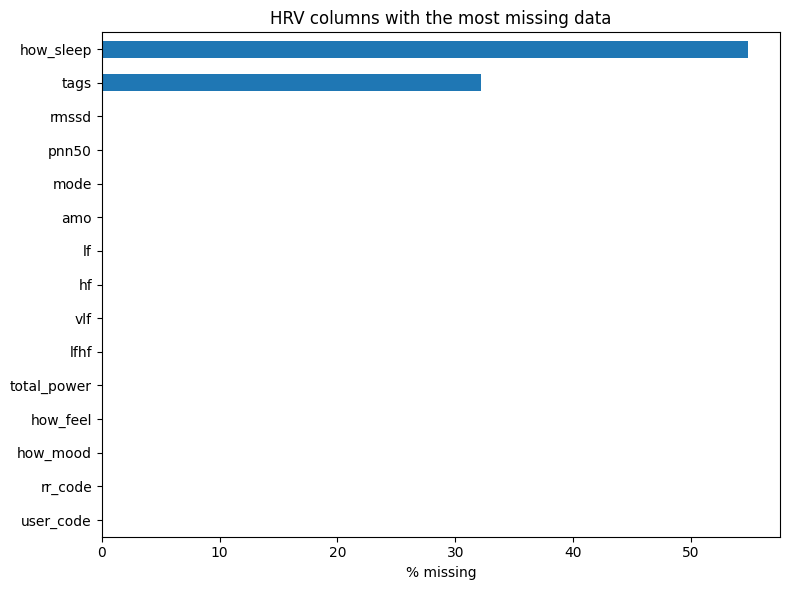

In [8]:
ax = hrv_missing.head(15).sort_values("missing_pct").plot(
    kind="barh",
    legend=False,
    figsize=(8, 6)
)
ax.set_xlabel("% missing")
ax.set_title("HRV columns with the most missing data")
plt.tight_layout()
plt.show()

## Missing-value decision

This exploratory analysis does not blanket-impute missing values. Many blanks may mean “not measured” rather than “measurement accidentally lost,” and inserting an average physiological value would erase that distinction. Instead, each analysis drops rows only when the variables required for that analysis are absent. A predictive-modeling project should additionally examine whether missingness is MCAR, MAR, or MNAR and consider missingness indicators where appropriate.

### Missingness interpretation

> how_sleep has substantial missingness (54.3%) because many users likely did not record sleep quality or sleep-related self-reports on every measurement day; this is likely because the question is only contextually relevant for morning measurements; if you take an HRV reading in the afternoon, evening, or night, the app either doesn't ask "How did you sleep?" Or the user skips it because it doesn't make sense at the time of the day. Therefore, missing is not random (not MCAR); it's tied to time_of_day. This is likely missing at random (MAR): The probability of the value being missing depends on the on an observed variable (time_of_day), not on the sleep quality itself. We can check this by noticing that how_sleep is almost entirely populated for time_of_day == 'morning' and almost entirely null otherwise. By contrast, how_feel and how_mood are always relevant regardless of when you measure, so the app always prompts for them and thus has zero missingness.
>
> Tags (32.2%) also has substantial missingness; it is described as "Tags assigned by user as a comma-separated string," such as "COVID-19; Workout; Sex; Hobby; Studying; Sleep..."; these are voluntary, user-initiated labels. The user has to actively choose to tag a measurement, so many users likely don't bother, especially on routine measurements where nothing notable happened. This missingness is also likely not random. Users are likely to tag a measurement when something noteworthy happened (felt sick, exercise, had COVID symptoms, etc.); therefore, routine "nothing special" measurements get no tags. This pattern is closer to Missing Not At Random (MNAR), as the probability of the value being missing is related to the (unobserved) absence of noteworthy events, which is the value itself.


# 7. Duplicates and integrity

There are two very different ideas:

1. **Exact duplicate row** — the same entire record appears twice.
2. **Repeated observation of the same person** — completely legitimate in longitudinal data.

A participant can have many HRV measurements. Therefore `user_code` **should repeat** in the HRV table.

But `rr_code` is documented as a unique HRV measurement ID, so duplicated `rr_code` values deserve investigation.

In [9]:
print("Exact duplicate participant rows:", participants.duplicated().sum())
print("Exact duplicate HRV rows:", hrv.duplicated().sum())
print("Exact duplicate survey rows:", surveys.duplicated().sum())

print()
print("Participant user_code unique?", participants["user_code"].is_unique)
print("HRV rr_code unique?", hrv["rr_code"].is_unique)

if not hrv["rr_code"].is_unique:
    display(
        hrv[hrv["rr_code"].duplicated(keep=False)]
        .sort_values("rr_code")
        .head(20)
    )

Exact duplicate participant rows: 0
Exact duplicate HRV rows: 0
Exact duplicate survey rows: 0

Participant user_code unique? True
HRV rr_code unique? True


## Referential integrity

An HRV observation whose `user_code` does not exist in `participants.csv` would be an orphan record. The analysis therefore checks foreign-key coverage before merging participant attributes into repeated HRV observations.


In [10]:
orphan_mask = ~hrv["user_code"].isin(participants["user_code"])

print("HRV orphan records:", orphan_mask.sum())
print("HRV orphan rate:", round(orphan_mask.mean() * 100, 3), "%")

HRV orphan records: 0
HRV orphan rate: 0.0 %


### Duplicate and integrity results

> Luckily there are no exact duplicates nor orphaned records.


# 8. Transform data types

CSV files store dates as text rather than native datetime values. Date arithmetic therefore requires parsing fields such as `measurement_datetime` and `symptoms_onset`. Original columns are retained while parsed versions are created for analysis.


In [11]:
participants["symptoms_onset"] = pd.to_datetime(
    participants["symptoms_onset"],
    errors="coerce"
)

hrv["measurement_datetime"] = pd.to_datetime(
    hrv["measurement_datetime"],
    errors="coerce"
)

surveys["created_at"] = pd.to_datetime(
    surveys["created_at"],
    errors="coerce"
)

wearables["day"] = pd.to_datetime(
    wearables["day"],
    errors="coerce"
)

print("Parsed HRV datetime failures:",
      hrv["measurement_datetime"].isna().sum())
print("Parsed symptom-onset missing/failed:",
      participants["symptoms_onset"].isna().sum())

Parsed HRV datetime failures: 0
Parsed symptom-onset missing/failed: 38


# 9. Feature engineering

Feature engineering transforms raw columns into variables that more directly represent the analytical question. This analysis creates `days_from_symptom_onset`, which indicates whether an HRV measurement occurred before, on, or after the participant's reported symptom-onset date. Participant-relative time is more useful for this question than comparing unrelated absolute calendar dates.


In [12]:
hrv_analysis = hrv.merge(
    participants[
        ["user_code", "gender", "age_range", "country", "height",
         "weight", "symptoms_onset"]
    ],
    on="user_code",
    how="left",
    validate="many_to_one"
)

hrv_analysis["days_from_symptom_onset"] = (
    hrv_analysis["measurement_datetime"].dt.normalize()
    - hrv_analysis["symptoms_onset"].dt.normalize()
).dt.days

display(
    hrv_analysis[
        ["user_code", "measurement_datetime",
         "symptoms_onset", "days_from_symptom_onset"]
    ].dropna().head(10)
)

,user_code,measurement_datetime,symptoms_onset,days_from_symptom_onset
2,013f6d3e5b,2020-05-15 04:14:21,2020-05-15,0.0
3,013f6d3e5b,2020-05-19 03:06:02,2020-05-15,4.0
4,01bad5a519,2019-12-31 09:07:43,2020-04-05,-96.0
5,01bad5a519,2020-01-11 14:52:39,2020-04-05,-85.0
6,01bad5a519,2020-01-30 17:55:54,2020-04-05,-66.0
7,01bad5a519,2020-04-02 12:07:09,2020-04-05,-3.0
8,01bad5a519,2020-04-12 15:00:58,2020-04-05,7.0
9,01bad5a519,2020-04-13 19:17:50,2020-04-05,8.0
10,01bad5a519,2020-04-17 08:47:30,2020-04-05,12.0
11,01bad5a519,2020-04-17 15:17:08,2020-04-05,12.0


### Additional engineered feature: BMI

BMI combines height and weight into a single ratio. It is included as an additional interaction feature, but it is not used to draw medical conclusions in this exploratory analysis.


In [13]:
hrv_analysis["height_m"] = hrv_analysis["height"] / 100
hrv_analysis["bmi"] = (
    hrv_analysis["weight"] / (hrv_analysis["height_m"] ** 2)
)

hrv_analysis[["height", "weight", "bmi"]].describe()

,height,weight,bmi
count,3237.000000,3245.000000,3237.000000
mean,169.589540,79.669604,27.757654
std,6.853155,19.999524,7.480809
min,132.080000,43.500000,13.143360
25%,166.000000,62.000000,22.185840
50%,168.000000,79.500000,26.808163
75%,175.000000,92.000000,31.249135
max,250.000000,154.221000,54.277185


### Rationale for the relative-time feature

> days_from_symptom_onset was calculated by normalizing measurement_datetime and symptoms_onset and calculating the difference, so it is easier to compare the two variables as one concept: did symptoms occur before, on, or after the HRV measurement. This makes relative time analytically useful than raw calendar dates.


# 10. Outliers — detect first, decide second

An outlier is an observation far from most others. It may represent sensor error, data-entry error, a processing artifact, or a genuine rare event. Statistical detection alone is therefore insufficient justification for deletion. Because RMSSD is skewed, the IQR method is used to flag unusual values without assuming a normal distribution.


In [14]:
rmssd_nonmissing = hrv["rmssd"].dropna()

q1 = rmssd_nonmissing.quantile(0.25)
q3 = rmssd_nonmissing.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

hrv["rmssd_iqr_outlier"] = (
    (hrv["rmssd"] < lower) |
    (hrv["rmssd"] > upper)
)

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower fence:", lower)
print("Upper fence:", upper)
print("Flagged RMSSD observations:", hrv["rmssd_iqr_outlier"].sum())
print("Percent flagged:",
      round(hrv["rmssd_iqr_outlier"].mean() * 100, 2), "%")

Q1: 28.985
Q3: 62.485
IQR: 33.5
Lower fence: -21.265
Upper fence: 112.735
Flagged RMSSD observations: 195
Percent flagged: 6.01 %


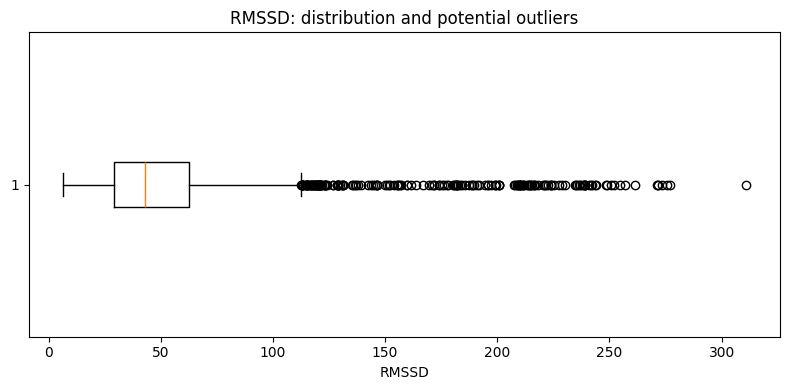

In [15]:
plt.figure(figsize=(8, 4))
plt.boxplot(rmssd_nonmissing, vert=False)
plt.xlabel("RMSSD")
plt.title("RMSSD: distribution and potential outliers")
plt.tight_layout()
plt.show()

## Outlier handling decision

Statistical outliers are flagged rather than deleted. Being outside an IQR fence establishes that a value is unusual, but not that it is incorrect; removal would require stronger domain knowledge or evidence of a collection or processing error. For visualization only, the displayed range may be limited to the 99th percentile so the main distribution remains readable without removing underlying observations.

### IQR result and rationale

> The IQR found that RMSSD varies mostly around 29 to 62; however, there are a substantial number of outliers ranging from approximately 110 to over 300. It makes sense to flag and investigate, but not to automatically delete, since the IQR only proves taht the values are unusual, but not that the measurement is wrong or not meaningful; removal would require stronger domain knowledge or evidence of a collection/processing error.


# 11. Visual exploration

The visual analysis uses a focused set of plots: a histogram for distribution shape, a scatter plot for a relationship between two numerical variables, a correlation heatmap for multiple numerical relationships, and a relative-time plot for change around symptom onset.


## 11A. Distribution of RMSSD

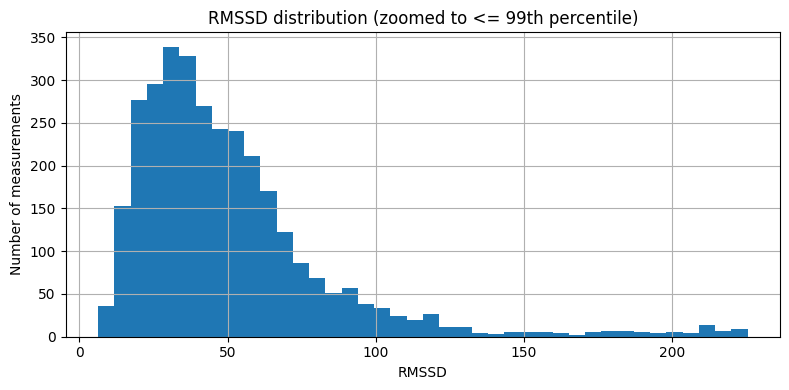

In [16]:
rmssd_99 = rmssd_nonmissing.quantile(0.99)

plt.figure(figsize=(8, 4))
hrv.loc[hrv["rmssd"] <= rmssd_99, "rmssd"].hist(bins=40)
plt.xlabel("RMSSD")
plt.ylabel("Number of measurements")
plt.title("RMSSD distribution (zoomed to <= 99th percentile)")
plt.tight_layout()
plt.show()

### Distribution interpretation

> This is a right-skewed distribution. So, unusual readings are clearly visible.


## 11B. Relationship between SDNN and RMSSD

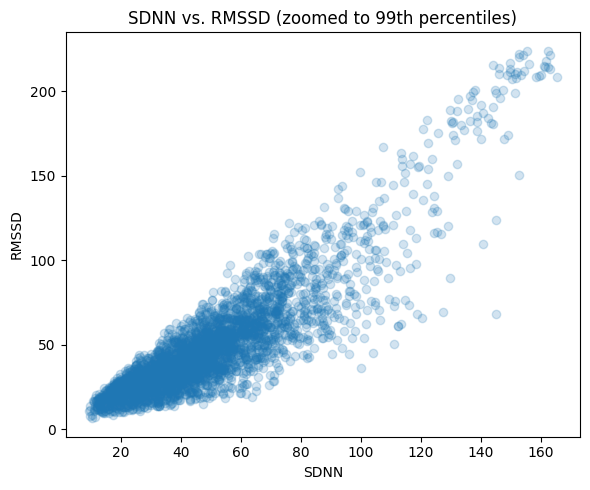

Pearson correlation: 0.909


In [17]:
plot_df = hrv[["sdnn", "rmssd"]].dropna()

# Zoom for readability without changing the stored dataset
sdnn_99 = plot_df["sdnn"].quantile(0.99)
rmssd_99 = plot_df["rmssd"].quantile(0.99)
plot_zoom = plot_df[
    (plot_df["sdnn"] <= sdnn_99) &
    (plot_df["rmssd"] <= rmssd_99)
]

plt.figure(figsize=(6, 5))
plt.scatter(plot_zoom["sdnn"], plot_zoom["rmssd"], alpha=0.2)
plt.xlabel("SDNN")
plt.ylabel("RMSSD")
plt.title("SDNN vs. RMSSD (zoomed to 99th percentiles)")
plt.tight_layout()
plt.show()

print("Pearson correlation:",
      round(plot_df["sdnn"].corr(plot_df["rmssd"]), 3))

### Relationship interpretation

> The relationship between SDNN and RMSSD is mostly strong, positive, and roughly linear. Although it is a correlation, the likely explanation is that they are related since they are two different methods of calculation HRV.


## 11C. Numerical correlation matrix

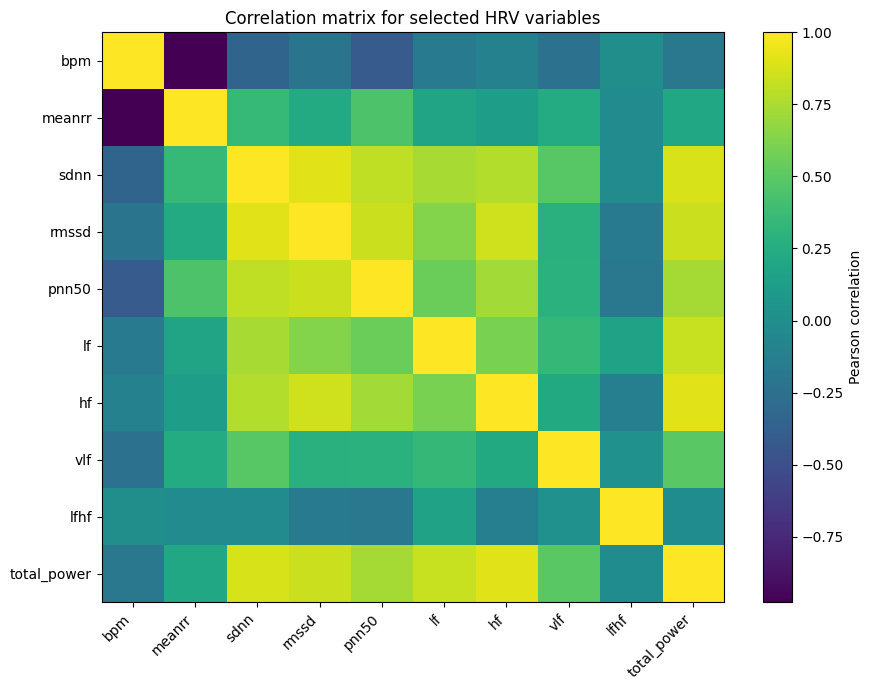

,bpm,meanrr,sdnn,rmssd,pnn50,lf,hf,vlf,lfhf,total_power
bpm,1.00,-0.98,-0.34,-0.21,-0.41,-0.17,-0.11,-0.24,-0.00,-0.18
meanrr,-0.98,1.00,0.35,0.23,0.45,0.18,0.13,0.24,-0.02,0.20
sdnn,-0.34,0.35,1.00,0.91,0.81,0.74,0.77,0.49,-0.02,0.88
rmssd,-0.21,0.23,0.91,1.00,0.84,0.63,0.86,0.27,-0.16,0.84
pnn50,-0.41,0.45,0.81,0.84,1.00,0.56,0.73,0.29,-0.18,0.74
lf,-0.17,0.18,0.74,0.63,0.56,1.00,0.60,0.34,0.16,0.83
hf,-0.11,0.13,0.77,0.86,0.73,0.60,1.00,0.23,-0.12,0.91
vlf,-0.24,0.24,0.49,0.27,0.29,0.34,0.23,1.00,0.02,0.49
lfhf,-0.00,-0.02,-0.02,-0.16,-0.18,0.16,-0.12,0.02,1.00,-0.01
total_power,-0.18,0.20,0.88,0.84,0.74,0.83,0.91,0.49,-0.01,1.00


In [18]:
corr_cols = [
    "bpm", "meanrr", "sdnn", "rmssd", "pnn50",
    "lf", "hf", "vlf", "lfhf", "total_power"
]

corr = hrv[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, aspect="auto")

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Correlation matrix for selected HRV variables")
plt.tight_layout()
plt.show()

corr.round(2)

### Correlation interpretation

> bpm and meanrr = -0.98; there is a near-perfect negative correlation, which makes sense as both are mathematically inverses of each other
>
> sdnn and rmssd = 0.91; they have a strong positive correlation; both measure HRV spread, just computed different; they're largely redundant
>
> lfhf ≈ 0; the LF/HF ratio barely correlates linearly with the other featuress


## 11D. New feature: HRV relative to symptom onset

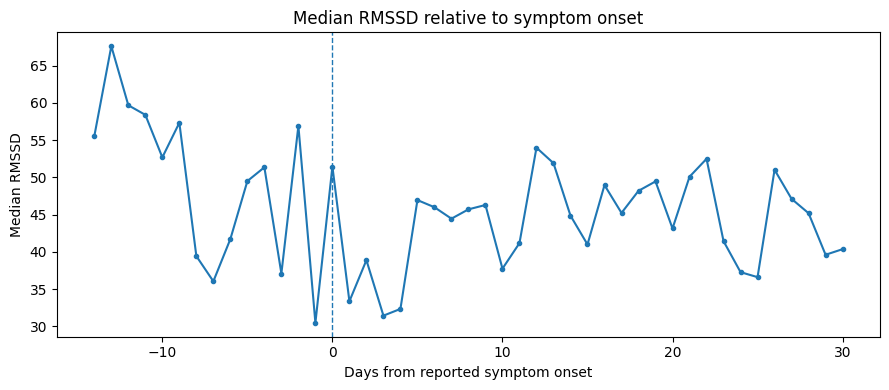

In [19]:
relative = hrv_analysis[
    ["days_from_symptom_onset", "rmssd"]
].dropna()

relative_window = relative[
    relative["days_from_symptom_onset"].between(-14, 30)
]

median_rmssd_by_day = (
    relative_window
    .groupby("days_from_symptom_onset")["rmssd"]
    .median()
)

plt.figure(figsize=(9, 4))
plt.plot(
    median_rmssd_by_day.index,
    median_rmssd_by_day.values,
    marker="o",
    markersize=3
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Days from reported symptom onset")
plt.ylabel("Median RMSSD")
plt.title("Median RMSSD relative to symptom onset")
plt.tight_layout()
plt.show()

### Symptom-onset visualization interpretation

> The plot suggests a downward range in the RMSSD (~55-65 down to ~30-50) in the days leading up to the first reported COVID symptom, before slightly rising over the next 30 days. More precisely, roughly the lowest 25% and highest 25% of RMSSD values in pre- and post-symptom onet seem to follow a downward and upward trend, respectively. A possible explanation is that environmental or biological factors, such as COVID, may have affected HRV; however, correlation does not imply causation, so further investigation would be required into HRV changes.


# 12. Accuracy and consistency checks

Data quality includes more than completeness; observed values and documentation must also be mutually plausible. The Welltory data dictionary describes `sleep_duration` in hours, but values in the CSV reach the tens of thousands, which is impossible under a literal hours interpretation. The magnitude suggests that the stored values may instead be seconds, or that the documentation and storage convention are inconsistent. This comparison illustrates why observed values should be validated against, rather than assumed to match, their documentation.


In [20]:
sleep = data["sleep"].copy()

display(
    sleep[
        ["sleep_begin", "sleep_end", "sleep_duration"]
    ].head(10)
)

print("sleep_duration summary:")
display(sleep["sleep_duration"].describe())

,sleep_begin,sleep_end,sleep_duration
0,2019-12-31 07:50:32,2019-12-31 08:45:22,3290.0
1,2020-01-01 04:13:41,2020-01-01 09:45:02,19881.0
2,2020-01-02 02:14:52,2020-01-02 08:06:00,21068.0
3,2020-01-03 00:10:00,2020-01-03 08:45:10,30910.0
4,2020-01-04 01:27:25,2020-01-04 08:52:20,26695.0
5,2020-01-05 01:00:42,2020-01-05 09:45:00,31458.0
6,2020-01-06 02:03:00,2020-01-06 07:11:00,18480.0
7,2020-01-07 01:09:51,2020-01-07 08:43:23,27212.0
8,2020-01-08 01:26:21,2020-01-08 08:46:28,26407.0
9,2020-01-09 00:38:11,2020-01-09 08:45:05,29214.0


sleep_duration summary:


count      425.000000
mean     25699.731765
std       7773.805470
min        930.000000
25%      21857.000000
50%      26041.000000
75%      30600.000000
max      47460.000000
Name: sleep_duration, dtype: float64

### Unit-consistency interpretation

> "Hours" does not look plausible as the stored unit; I would consider the fact that dictionary is potentially inaccurate in describing sleep_duration as hours, and rather, is measured in seconds. I would make analysis based on seconds, but make a note that the analysis could be limited until a correction is made to clarify.


# 13. Structured Data Quality Assessment (DQA)

| Dimension | What we checked | Your conclusion |
|---|---|---|
| **Profiling** | shapes, dtypes, descriptive statistics, distributions | The HRV table (3,245 rows × 22 columns) is the main analysis table. Dtypes are a mix of floats, ints, and objects (the latter requiring parsing for datetimes and tags). Descriptive statistics revealed right-skewed distributions for frequency-domain features (`lf`, `hf`, `vlf`, `total_power`, `lfhf`) where the mean consistently exceeds the median, indicating outlier-driven skew. Self-report fields (`how_feel`, `how_mood`, `how_sleep`) are ordinal (-2 to +2), not continuous. |
| **Completeness** | missing percentages and sparse fields | Most HRV physiological columns are 100% complete. The two main gaps are `how_sleep` (~55% missing) and `tags` (~32% missing). `how_sleep` missingness is likely MAR - tied to `time_of_day`, since the "How did you sleep?" question is only relevant for morning measurements. `tags` missingness is likely MNAR - users only tag measurements when something noteworthy happened. Across all tables, the sleep and wearables tables are the sparsest (56% and 48% overall missing cells, respectively), largely because not all participants had connected devices collecting those metrics. |
| **Accuracy** | plausible ranges / suspicious values / documentation checks | BPM values (44–125) are physiologically plausible. RMSSD outliers above ~110 ms are unusual but not impossible for young/healthy individuals - flagged but not deleted. The sleep table's `sleep_duration` documentation says "hours," but observed values (e.g., in the thousands) suggest the actual unit is seconds; this must be verified before any analysis uses that column. The `how_feel` and `how_mood` columns encode 0 as "neutral" rather than as missing, which could be misinterpreted without the data dictionary. |
| **Consistency** | date formats, units, conventions across files | Date formats are inconsistent: `measurement_datetime` in HRV uses `YYYY-MM-DD hh:mm:ss`, while `symptoms_onset` in participants uses `MM/DD/YYYY`. Units are mostly consistent within the HRV table (milliseconds for time-domain, ms² for frequency-domain) but the sleep table's `sleep_duration` unit contradicts its documentation. Categorical encoding also varies - self-report scores are integers in HRV but the survey table uses a different scale/codebook (`scales_description`). |
| **Integrity** | unique IDs, duplicates, orphan foreign keys, safe merge validation | No exact duplicate rows were found in any table. `rr_code` is unique across HRV rows (3,245 unique values = 3,245 rows). All 185 participant `user_code` values are unique. When merging HRV with participants, we confirmed no orphan foreign keys - every `user_code` in HRV exists in participants. The merge produced no row duplication, confirming a clean many-to-one join. |
| **Lineage & provenance** | 2020 Welltory research; app / PPG / Bluetooth monitors / connected wearables / surveys → anonymized CSVs | Data was collected in 2020 by Welltory as part of a voluntary COVID-19 research project. HRV measurements come from multiple sources: smartphone camera (PPG), Bluetooth heart-rate monitors, and the Welltory app itself - meaning measurement quality and method are heterogeneous across participants. Connected wearable data (Apple Watch, Garmin via Apple Health/Google Fit) feeds the wearables and sleep tables. Data was anonymized (hashed user/measurement IDs) and published as CSVs on GitHub. The voluntary, self-selected sample of Welltory users introduces selection and volunteer bias. |


# 14. Data story

**Setup:**  
The Welltory dataset combines repeated HRV measurements with self-reported symptoms, wearable data, and participant demographics across 185 COVID-19 participants.

**Tension:**  
Tables are heterogeneous and incomplete - `how_sleep` is missing for over half of rows because it is only relevant for morning measurements, `tags` missingness may signal "nothing noteworthy happened," documented units (e.g., sleep_duration) contradict observed values, and date formats vary across files. Blindly imputing or joining without understanding these issues would invent data that never existed.


**Resolution:**  
Before any predictive modeling, standardize date formats, verify and correct unit documentation (especially sleep_duration), preserve meaningful missingness as a signal rather than filling it, enforce ID integrity across joins, and engineer participant-relative time features (e.g., days since symptom onset) rather than modeling raw rows.


# 15. Final conclusions

The Welltory dataset is a multi-table, heterogeneous collection where missingness is often meaningful (e.g., `how_sleep` is blank when the question was not contextually relevant, not because of measurement failure). The biggest quality concerns are inconsistent date formats across tables, a documented unit contradiction in `sleep_duration`, and right-skewed frequency-domain HRV features with extreme outliers. I chose to flag outliers rather than delete them (since unusual ≠ wrong) and to drop rows only per-analysis rather than blanket-imputing missing values. The engineered `days_since_onset` feature anchors each measurement relative to the participant's symptom timeline. Before fitting a predictive model, one should standardize dates/units, validate the sleep_duration unit, and treat missingness as an informative feature rather than noise.
